# U-Net con ResNet34

En esta etapa se implementó una arquitectura U-Net utilizando ResNet34 como encoder preentrenado mediante la librería `segmentation-models-pytorch`.

El objetivo fue evaluar el impacto del transfer learning y de arquitecturas más robustas en la detección de áreas afectadas por deforestación.

In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.0 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split

import segmentation_models_pytorch as smp

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
tiles_path1 = "/content/drive/MyDrive/vision_sentinental_drive/tiles_par1"
labels_path1 = "/content/drive/MyDrive/vision_sentinental_drive/labels_par1"

tiles_path2 = "/content/drive/MyDrive/vision_sentinental_drive/tiles_par2"
labels_path2 = "/content/drive/MyDrive/vision_sentinental_drive/labels_par2"

tiles_path3 = "/content/drive/MyDrive/vision_sentinental_drive/tiles_par3"
labels_path3 = "/content/drive/MyDrive/vision_sentinental_drive/labels_par3"

In [ ]:
class ChangeDetectionDataset(Dataset):

    def __init__(self, tiles_dirs, labels_dirs):

        self.samples = []

        # recorrer todos los pares
        for tiles_dir, labels_dir in zip(
            tiles_dirs,
            labels_dirs
        ):

            ids = sorted([
                f.split("_")[1]
                for f in os.listdir(tiles_dir)
                if "pre" in f
            ])

            for tile_id in ids:

                self.samples.append(
                    (tiles_dir, labels_dir, tile_id)
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        tiles_dir, labels_dir, tile_id = self.samples[idx]

        # =========================
        # CARGAR PRE
        # =========================
        pre = np.load(
            os.path.join(
                tiles_dir,
                f"tile_{tile_id}_pre.npy"
            )
        )

        # =========================
        # CARGAR POST
        # =========================
        post = np.load(
            os.path.join(
                tiles_dir,
                f"tile_{tile_id}_post.npy"
            )
        )

        # =========================
        # SOLO RGB
        # =========================
        pre = pre[:3]
        post = post[:3]

        # =========================
        # CONCATENAR
        # =========================
        x = np.concatenate(
            [pre, post],
            axis=0
        )

        # =========================
        # LABEL
        # =========================
        label = np.load(
            os.path.join(
                labels_dir,
                f"tile_{tile_id}_label.npy"
            )
        )

        label = np.expand_dims(
            label,
            axis=0
        )

        # =========================
        # TENSORES
        # =========================
        x = torch.tensor(
            x,
            dtype=torch.float32
        )

        label = torch.tensor(
            label,
            dtype=torch.float32
        )

        return x, label

In [ ]:
tiles_dirs = [
    tiles_path1,
    tiles_path2,
    tiles_path3
]

labels_dirs = [
    labels_path1,
    labels_path2,
    labels_path3
]

dataset = ChangeDetectionDataset(
    tiles_dirs,
    labels_dirs
)

print("Total samples:", len(dataset))

x, y = dataset[0]

print("Input shape :", x.shape)
print("Label shape :", y.shape)

Total samples: 48
Input shape : torch.Size([6, 512, 512])
Label shape : torch.Size([1, 512, 512])


In [ ]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

Train: 38
Val: 10


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False
)

In [ ]:
x, y = next(iter(train_loader))

print(x.shape)
print(y.shape)

torch.Size([2, 6, 512, 512])
torch.Size([2, 1, 512, 512])


In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=6,
    classes=1
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Modelo cargado")
print(device)

Modelo cargado
cpu


In [ ]:
pos_weight = torch.tensor([3.0]).to(device)

criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print("Loss y optimizer listos")

Loss y optimizer listos


In [ ]:
num_epochs = 30

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # ======================
    # TRAIN
    # ======================
    model.train()

    train_loss = 0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        y_pred = model(x)

        loss = criterion(y_pred, y)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ======================
    # VALIDACIÓN
    # ======================
    model.eval()

    val_loss = 0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(device)
            y = y.to(device)

            y_pred = model(x)

            loss = criterion(y_pred, y)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1/2 | Train Loss: 0.9428 | Val Loss: 1.1384
Epoch 2/2 | Train Loss: 0.7738 | Val Loss: 1.0949


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    confusion_matrix
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for x, y in val_loader:

        x = x.to(device)
        y = y.to(device)

        y_pred = model(x)

        y_pred = torch.sigmoid(y_pred)

        threshold = 0.5

        y_pred_bin = (y_pred > threshold).float()

        y_pred_bin = y_pred_bin.cpu().numpy()
        y = y.cpu().numpy()

        y_pred_bin = y_pred_bin.flatten()
        y = y.flatten()

        all_preds.extend(y_pred_bin)
        all_labels.extend(y)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels,
    all_preds,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_preds,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_preds,
    zero_division=0
)

iou = jaccard_score(
    all_labels,
    all_preds,
    zero_division=0
)

cm = confusion_matrix(
    all_labels,
    all_preds
)

print("\n========== MÉTRICAS ==========")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"IoU       : {iou:.4f}")

print("\n===== MATRIZ DE CONFUSIÓN =====")
print(cm)


========== MÉTRICAS ==========
Accuracy  : 0.5209
Precision : 0.3141
Recall    : 0.9357
F1-Score  : 0.4703
IoU       : 0.3075

===== MATRIZ DE CONFUSIÓN =====
[[ 808086 1217500]
 [  38331  557523]]


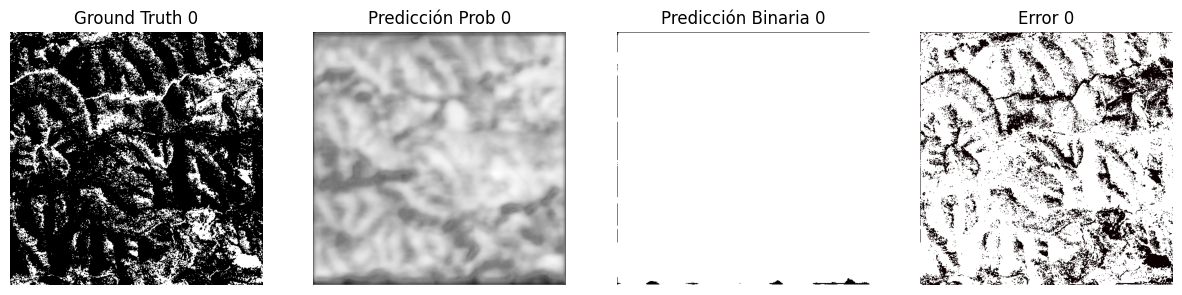

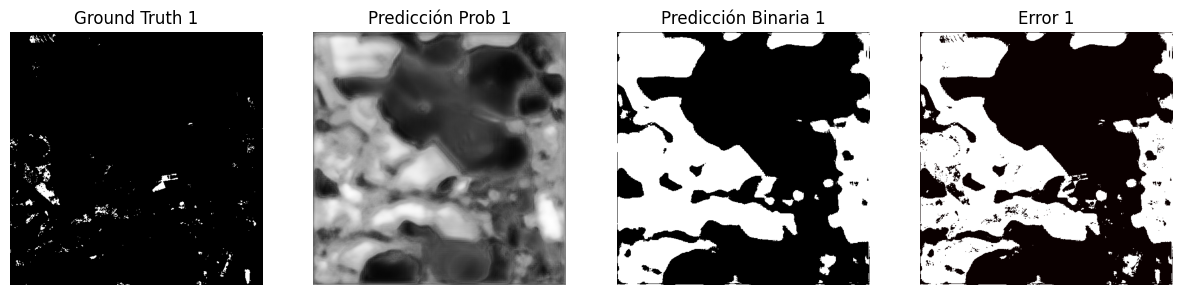

In [ ]:
model.eval()

x, y = next(iter(val_loader))

x = x.to(device)

with torch.no_grad():

    y_pred = model(x)

    y_pred = torch.sigmoid(y_pred)

x = x.cpu()
y = y.cpu()
y_pred = y_pred.cpu()

num_ejemplos = min(4, x.shape[0])

for i in range(num_ejemplos):

    pred_bin = (y_pred[i,0] > 0.5).float()

    error = torch.abs(
        y[i,0] - pred_bin
    )

    plt.figure(figsize=(15,5))

    # Ground Truth
    plt.subplot(1,4,1)
    plt.imshow(y[i,0], cmap="gray")
    plt.title(f"Ground Truth {i}")
    plt.axis("off")

    # Probabilidad
    plt.subplot(1,4,2)
    plt.imshow(y_pred[i,0], cmap="gray")
    plt.title(f"Predicción Prob {i}")
    plt.axis("off")

    # Binaria
    plt.subplot(1,4,3)
    plt.imshow(pred_bin, cmap="gray")
    plt.title(f"Predicción Binaria {i}")
    plt.axis("off")

    # Error
    plt.subplot(1,4,4)
    plt.imshow(error, cmap="hot")
    plt.title(f"Error {i}")
    plt.axis("off")

    plt.show()